In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure4/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,Homo sapiens


### FIGURE 4a/d

In [23]:
adata_positive_early_sgn_hm=sc.read('human_sgn_harmony_integration_early_sgn.h5ad')
adata_positive_gradual_sgn_hm=sc.read('human_sgn_harmony_integration_gradual_sgn_revision2.h5ad')
adata_positive_final_sgn_hm=sc.read('human_sgn_harmony_integration_final_sgn_revision2.h5ad')

In [24]:
adata_positive_early_sgn_hm.obs['batch'].value_counts()
adata_positive_early_sgn_hm.obs['timeperiod']='9-11gw'
adata_positive_gradual_sgn_hm.obs['batch'].value_counts()
adata_positive_gradual_sgn_hm.obs['timeperiod']='14-18gw'
adata_positive_final_sgn_hm.obs['batch'].value_counts()
adata_positive_final_sgn_hm.obs['timeperiod']='20-26gw'

batch
gw11.2    283
gw9.5     263
Name: count, dtype: int64

batch
gw18    67
GW14    20
gw16    20
gw17    20
Name: count, dtype: int64

batch
gw25    63
gw20    53
gw26    17
Name: count, dtype: int64

In [25]:
import anndata
adata_sgn_raw = anndata.concat([adata_positive_final_sgn_hm,adata_positive_gradual_sgn_hm,adata_positive_early_sgn_hm],join='outer',)
adata_sgn_raw

AnnData object with n_obs × n_vars = 806 × 24804
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'leiden_R', 'cell_type', 'doublet_score', 'predicted_doublet', 'leiden_0.8', 'leiden_0.4', 'C_subtype', 'timeperiod'
    obsm: 'X_harmony', 'X_pca', 'X_umap'

In [26]:
sc.pp.normalize_total(adata_sgn_raw, target_sum=1e4)
sc.pp.log1p(adata_sgn_raw)

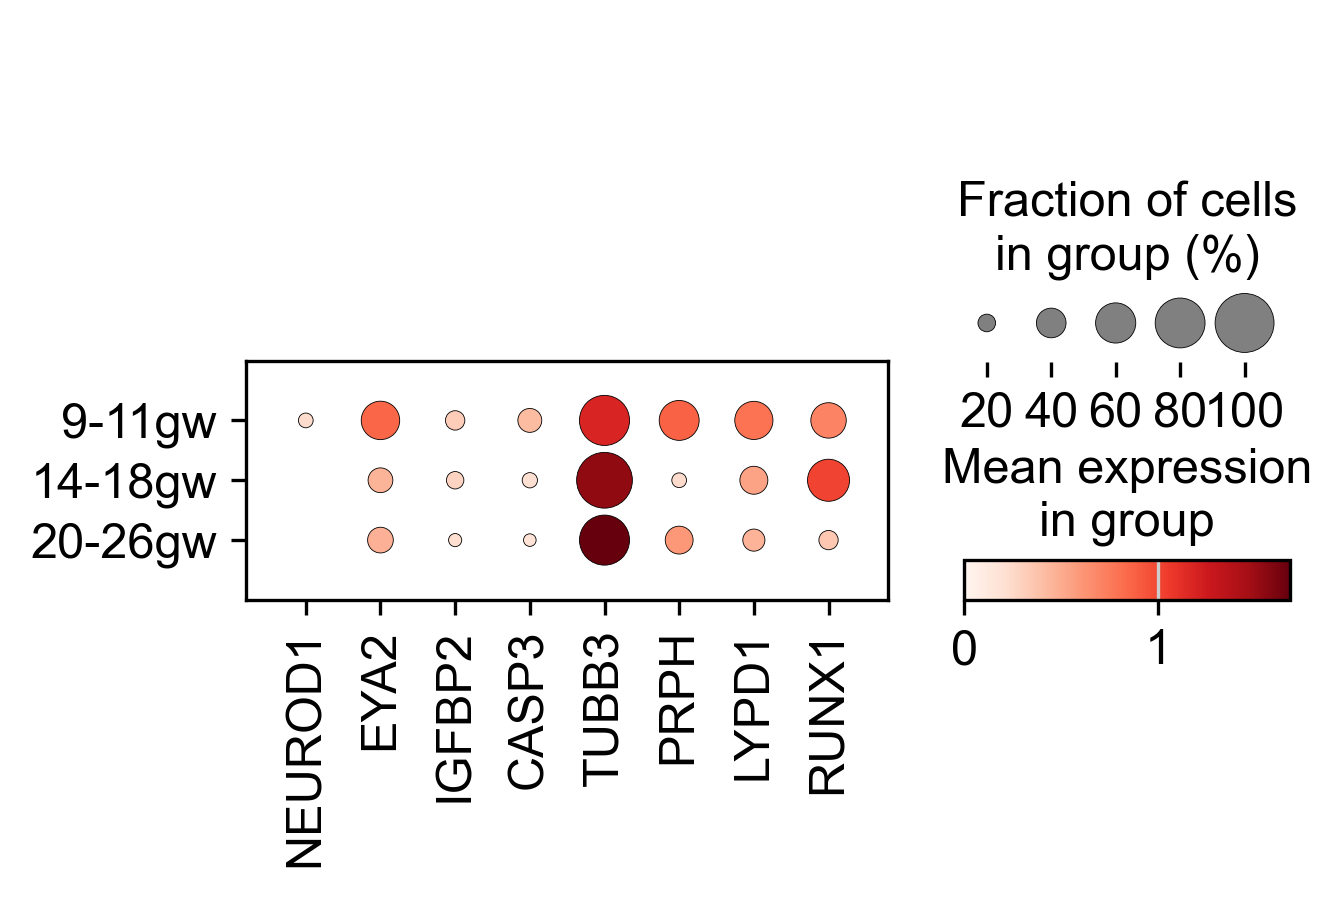

In [33]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(adata_sgn_raw, var_names=['NEUROD1','EYA2','IGFBP2','CASP3','TUBB3'
                                    ,'PRPH','LYPD1','RUNX1',
                                                     ],
              groupby='timeperiod', 
             #standard_scale='var',
              save="_human_sgn_timeperiod.pdf",
             )#standard_scale='var',swap_axes=True,

In [28]:
# cluster 2 name as IGFBP2+_intermediate_sgn
# clusetr 1 name as LYPD1+_immature_sgn
# cluster 0 name as CLU+_immature_sgn
cluster_annotation = {
 '0': 'NEFH+/RUNX1+/LYPD1+_mature_sgn',
     '1': 'NEFH+_mature_sgnn',
     '2': 'RUNX1+/LYPD1+_mature_sg',
          

}
adata_positive_final_sgn_hm.obs['cell_type_final'] = adata_positive_final_sgn_hm.obs['leiden_0.4'].map(cluster_annotation).astype('category')

In [29]:
sc.pp.normalize_total(adata_positive_final_sgn_hm)
sc.pp.log1p(adata_positive_final_sgn_hm)

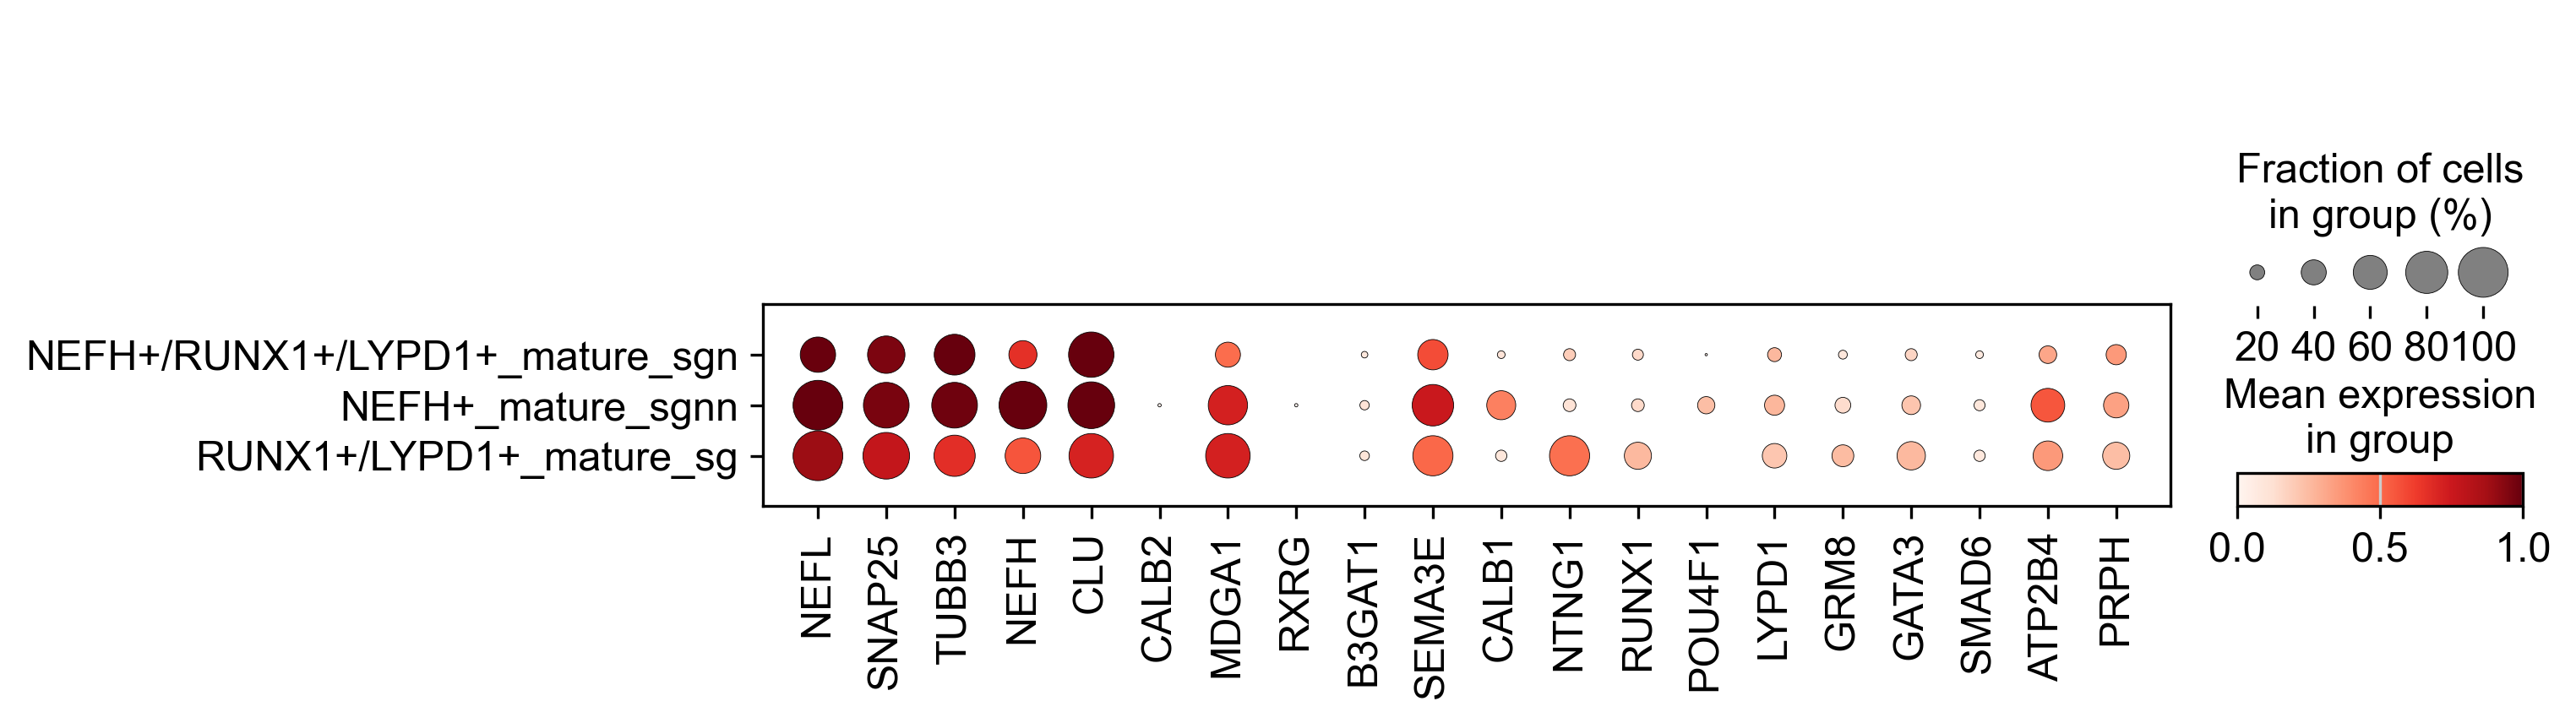

In [32]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(adata_positive_final_sgn_hm, var_names=["NEFL","SNAP25","TUBB3","NEFH", "CLU", #TYPE I SGN 
                                                      #'PROX1','ESRRG',
                   "CALB2","MDGA1","RXRG","B3GAT1", #IA
                   "SEMA3E", "CALB1","NTNG1",    #IB
                   "RUNX1", "POU4F1","LYPD1","GRM8",            #IC
                   "GATA3","SMAD6","ATP2B4","PRPH" #TYPE II
                                                     ],
              groupby='cell_type_final', vmax=1,
              save="_human_final_sgn_cell_type_rename_revision2.pdf",
             #standard_scale='var'
             )#standard_scale='var',swap_axes=True,

### FIGURE 4i/j

In [60]:
adata_sgn=sc.read('human_sgn_scANVI_integration_v2.h5ad')

In [36]:
genes=[
    'NEUROD1','CDH2','CELF4',
    'GATA3','IGFBP2','SIX1',
    'SLIT3','LYPD1',
    'ROR2','GPC6',
    'NTNG1','GRM8','FN1',
    'RUNX1','CAMK2B','HOMER1',
    'CLU','NEFH','SYT11',
]

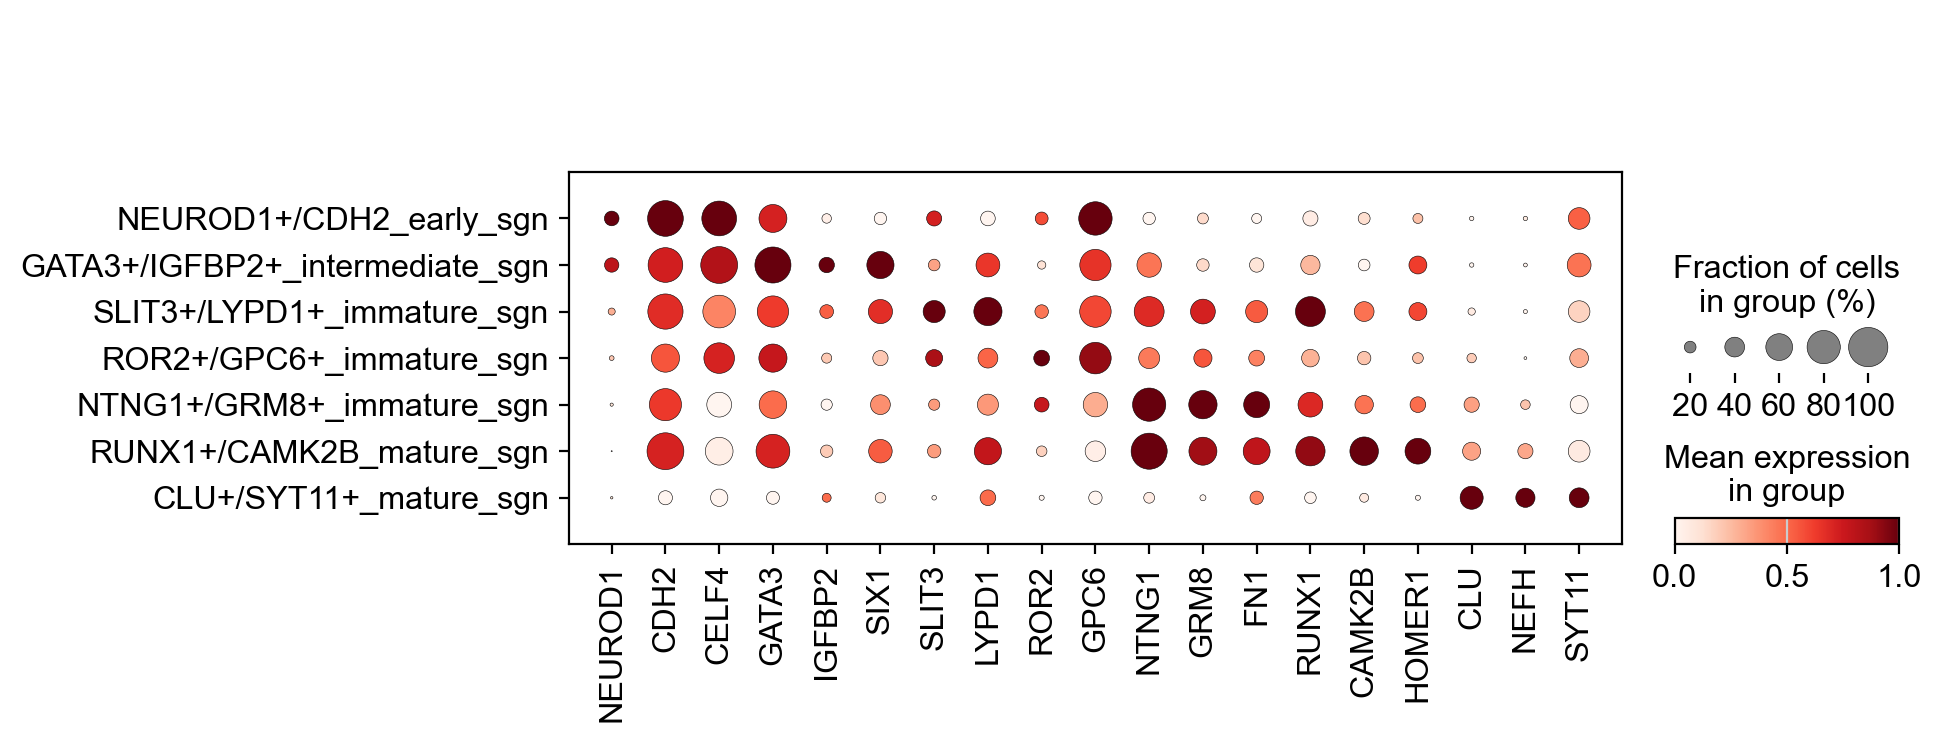

In [37]:
sc.set_figure_params(figsize=(4,5),frameon=False,dpi=100,dpi_save=600)
cell_type_order = [
    'NEUROD1+/CDH2_early_sgn',
    'GATA3+/IGFBP2+_intermediate_sgn',
    'SLIT3+/LYPD1+_immature_sgn',
    'ROR2+/GPC6+_immature_sgn',
    'NTNG1+/GRM8+_immature_sgn',
    'RUNX1+/CAMK2B_mature_sgn',
    'CLU+/SYT11+_mature_sgn'
]

adata_sgn.obs['cell_type_final_v2'] = pd.Categorical(
    adata_sgn.obs['cell_type_final_v2'],
    categories=cell_type_order,
    ordered=True
)

adata_sgn = adata_sgn[
    adata_sgn.obs['cell_type_final_v2'].sort_values().index
]

sc.pl.dotplot(
    adata_sgn, 
    var_names=genes,
    groupby='cell_type_final_v2', 
    standard_scale='var', #swap_axes=True,
    save="_human_sgn_cell_type_final_v2.pdf"
)

In [38]:
palette2={
             "SLIT3+/LYPD1+_immature_sgn": "#62edd0",
              "CLU+/SYT11+_mature_sgn": "#575add",
              "RUNX1+/CAMK2B_mature_sgn": "#e8ba69",
              "GATA3+/IGFBP2+_intermediate_sgn": "#74c5e9",
              "NEUROD1+/CDH2_early_sgn": "#1db342",
              "NTNG1+/GRM8+_immature_sgn": "#9b5792",
              "ROR2+/GPC6+_immature_sgn": "#b7de27",
            
            }

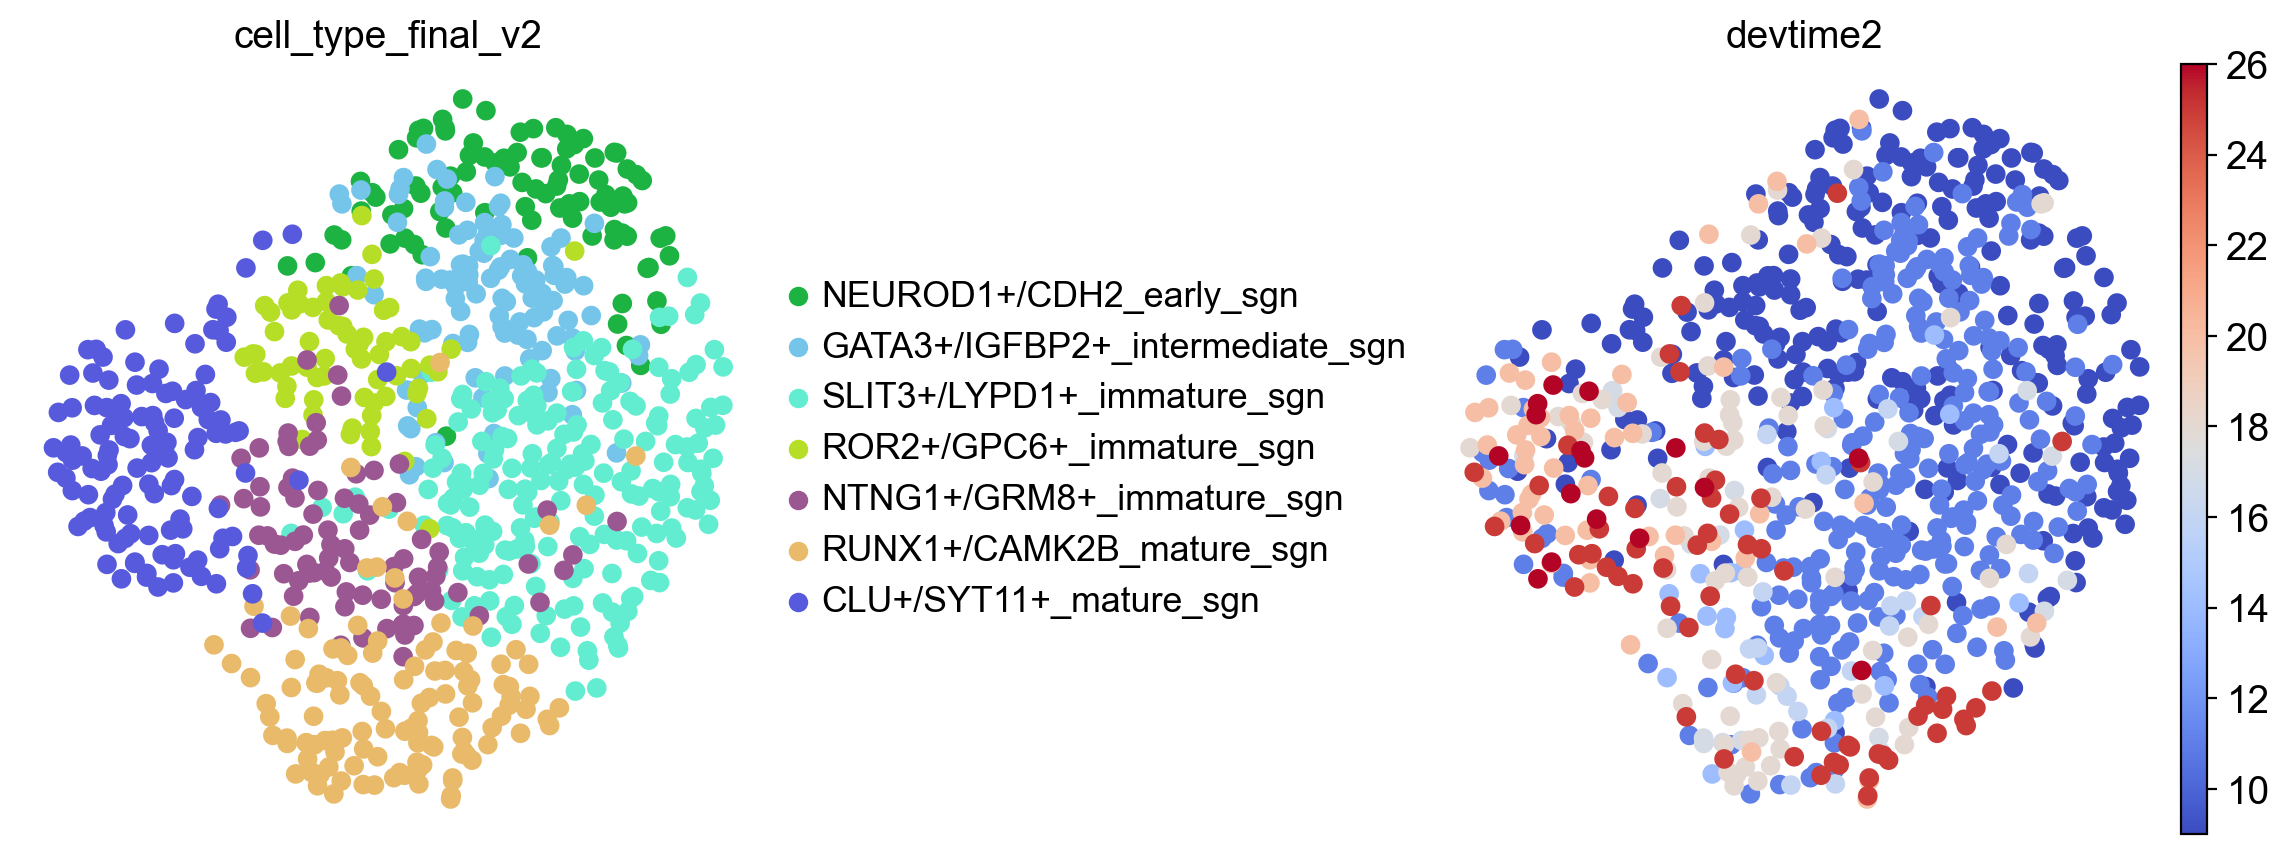

In [45]:
sc.set_figure_params(figsize=(4,5),frameon=False,dpi=100,dpi_save=600)
sc.pl.umap(adata_sgn, 
           color=['cell_type_final_v2','devtime2' ],  
           size=200, 
           wspace=0.75, palette=palette2,
           ncols=2, 
           color_map="coolwarm", save='_human_sgn_ctype_annotation_final.pdf'
           )

### FIGURE 4k

In [54]:
import scvelo as scv
scv.set_figure_params(figsize=(4,4))
import matplotlib.pyplot as plt

In [61]:
adata_SGN_ALL=adata_sgn.copy()
sc.pp.normalize_total(adata_SGN_ALL)
sc.pp.log1p(adata_SGN_ALL)
adata_SGN_ALL.layers["logcounts"]=adata_SGN_ALL.X.copy()
adata_SGN_ALL.layers["scaled"]=sc.pp.scale(adata_SGN_ALL.X,max_value=5,copy=True)
adata_SGN_ALL

AnnData object with n_obs × n_vars = 806 × 24804
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'leiden_R', 'cell_type', 'doublet_score', 'predicted_doublet', 'leiden_0.8', 'leiden_0.4', 'cell_type_final', 'scVI_res_1', 'scANVI_res2.0', 'scANVI_res0.8', 'scANVI_res1.0', 'devtime', 'devtime2', 'cell_type_final_v2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'cell_type_final_v2_colors', 'devtime_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'scANVI_res0.8', 'scANVI_res0.8_colors', 'scANVI_res1.0', 'scANVI_res1.0_colors', 'scANVI_res2.0', 'scVI_res_1', 'scVI_res_1_colors', 'umap'
    obsm: 'X_harmony', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'connectivities', 'distances'

Text(0.5, 1.0, 'NEUROD1')

Text(0.5, 1.0, 'EYA2')

Text(0.5, 1.0, 'PBX3')

Text(0.5, 1.0, 'CLU')

Text(0.5, 1.0, 'ESRRG')

Text(0.5, 1.0, 'PROX1')

Text(0.5, 1.0, 'RUNX1')

Text(0.5, 1.0, 'LYPD1')

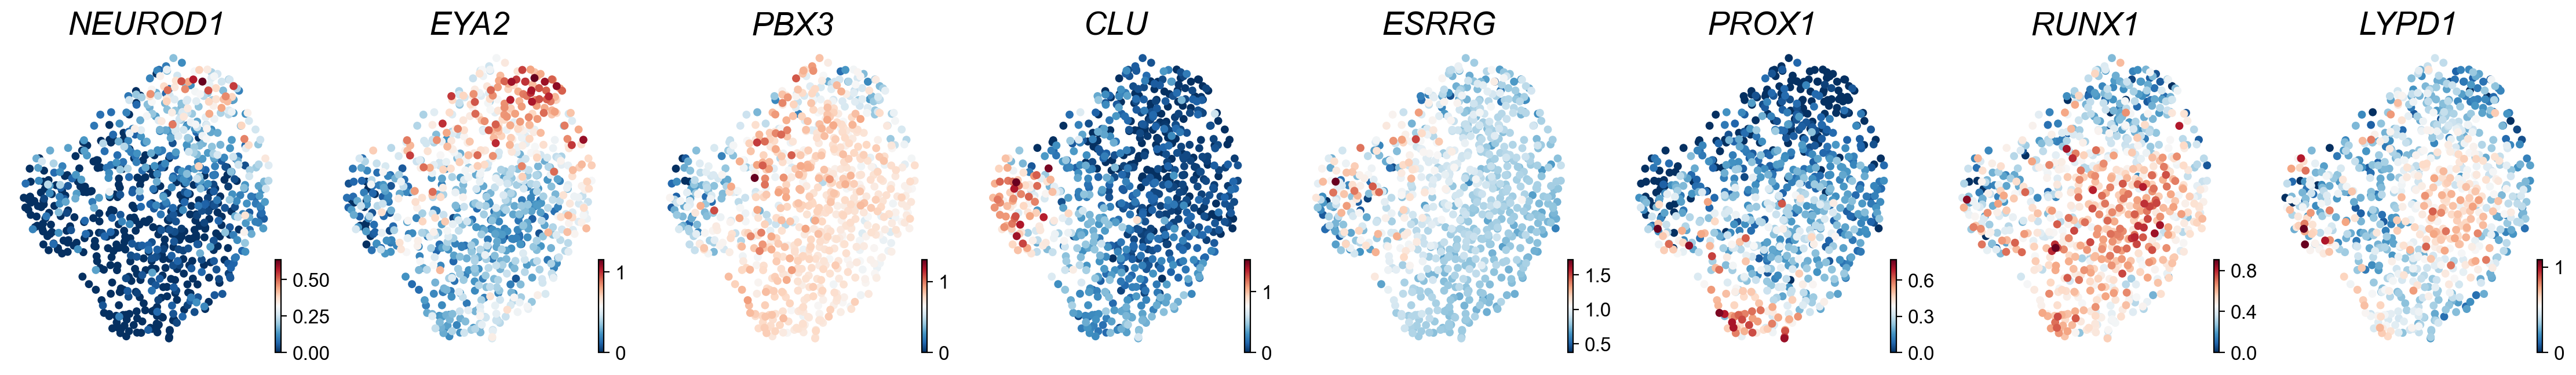

In [62]:
scv.set_figure_params(figsize=(3.5,3.5))
SGN=['NEUROD1','EYA2','PBX3',"CLU","ESRRG","PROX1","RUNX1","LYPD1"]
axs=scv.pl.umap(adata_SGN_ALL,color=SGN,smooth=True,show=False,size=100)
for ax in axs:
    ax.set_title(ax.get_title(),style="italic",fontsize=20)
plt.savefig(data_dir+"figures/figure4/SGN_HUMAN_TFS.pdf",dpi=600)

### FIGURE 4m

In [57]:
adata=adata_sgn.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["logcounts"]=adata.X.copy()
adata.layers["scaled"]=sc.pp.scale(adata.X,max_value=5,copy=True)
adata

AnnData object with n_obs × n_vars = 806 × 24804
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'leiden_R', 'cell_type', 'doublet_score', 'predicted_doublet', 'leiden_0.8', 'leiden_0.4', 'cell_type_final', 'scVI_res_1', 'scANVI_res2.0', 'scANVI_res0.8', 'scANVI_res1.0', 'devtime', 'devtime2', 'cell_type_final_v2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'cell_type_final_v2_colors', 'devtime_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'scANVI_res0.8', 'scANVI_res0.8_colors', 'scANVI_res1.0', 'scANVI_res1.0_colors', 'scANVI_res2.0', 'scVI_res_1', 'scVI_res_1_colors', 'umap'
    obsm: 'X_harmony', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'connectivities', 'distances'

In [51]:
genes2=[#NEUROD1+_early_sgn:
    'CDH2','DISC1','FGF13','SOX5','TAFA1',# GO:0061351 NEURAL PRECURSOR CELL PROLIFERATION
    
    
    #IGFBP2+_intermediate_sgn:
    'BCAR3','EPHB1','GATA3','LHFPL5','SIX1',# GO:0090596 SENSORY ORGAN MORPHOGENESIS
    
    'CASP3','EYA2','IL7', # GO:0045165 CELL FATE COMMITMENT
    
    #PRPH+_immature_sgn:
    'GPC6','ROR2', #GO:0060071 WNT SIG.PATHWAY,PLANAR CELL POLARITY PATHWAY
    'ARHGAP24','TENM2', #GO:0060491 REGULATION OF CELL PROJECTION ASSEMBLY

    #LYPD1+_immature_sgn:
    'FANCA','RUNX1','SH3RF1', # GO:0030217 T CELL DIFFERENTIATION
    'SLIT3', #GO:0070099 REGULATION OF CHEMOKINE-MEDIATED SIGNALING PATHWAY / GO:0007422 PERIPHERAL NERVOUS SYSTEM DEV.
    
    #ALDH1A3+_immature_sgn:
    
    'CHL1','FN1','LGI1','NRP1','NTNG1', # GO:0007409 AXONGENESIS AXON GUIDANCE
    
    #RUNX1+_mature_sgn
    'ARHGAP44','CAMK2B','CAPRIN2','CHRNA7','HOMER1','LGMN','RELN',# GO:0097061 DENDRITIC SPINE ORGANIZATION
    
    #CLU+_mature_sgn
    'CALM1','CALM3','CPLX1','RAB3A','RPH3A','SNAP25','SYT11','SYT4','VAMP2', #GO:0007269 NEUROTRANSMITTER SECRETION
    
                                              ]

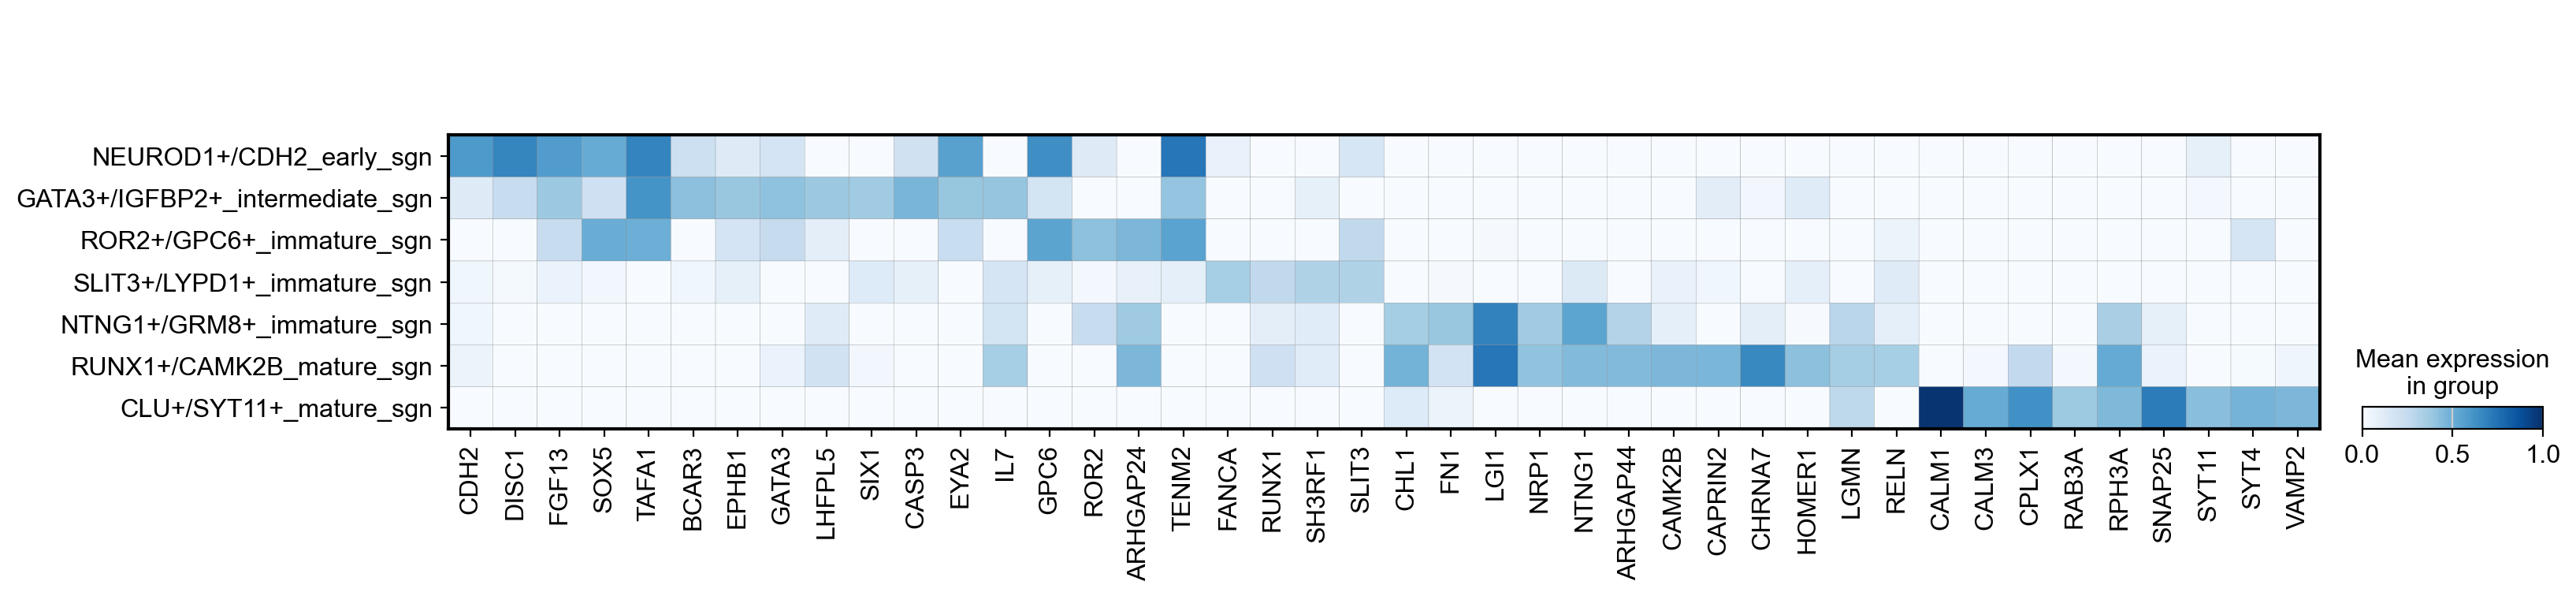

In [53]:
cell_type_order = [
    'NEUROD1+/CDH2_early_sgn',
    'GATA3+/IGFBP2+_intermediate_sgn',
    'ROR2+/GPC6+_immature_sgn',
    'SLIT3+/LYPD1+_immature_sgn',
    'NTNG1+/GRM8+_immature_sgn',
    'RUNX1+/CAMK2B_mature_sgn',
    'CLU+/SYT11+_mature_sgn'
]

adata.obs['cell_type_final_v2'] = pd.Categorical(
    adata.obs['cell_type_final_v2'],
    categories=cell_type_order,
    ordered=True
)


adata = adata[
    adata.obs['cell_type_final_v2'].sort_values().index
]


sc.set_figure_params(figsize=(4,4),frameon=False,dpi=100,dpi_save=600)
gs=sc.pl.matrixplot(adata,genes2, groupby='cell_type_final_v2',layer='scaled',vmin=0,cmap='Blues',vmax=1,
                    save="_human_sgn_cell_DEGs_go_v3.pdf")